# Approach 1 (real FPbase data) — guided design with trained surrogate + oracle

Property-guided FP design on the **real FPbase splits** (`training_data/`). Two models are trained,
tuned, saved, and wired into the design loop:

1. **Surrogate** `g(seq)->spectrum` — an MLP on frozen ESM-2 embeddings. **Guides** design. Grid-searched on
   the surrogate val split, evaluated on the surrogate **test** split.
2. **Oracle** — a **RandomForest** (different architecture) on the same embeddings, predicting a PCA-reduced
   spectrum. **Evaluates** designs (independent judge). Grid-searched on the oracle val split, evaluated on the
   oracle **test** split, reported **separately for the surrogate-seen (ID) and surrogate-unseen (OOD)** regions.

Then the design loop scores candidates with the surrogate (`z(log p_ESM) - lam * z(g-error)`) and is judged
by the oracle, reported for ID vs OOD targets. (The synthetic-data version is archived under `archive/`.)

## 0. Setup

In [1]:
import csv, os, time, json, itertools
import numpy as np
import torch, torch.nn as nn
import esm
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
import joblib
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False

TD = "training_data"
DS = os.path.join("..", "fpbase-extractor", "processed_data", "ESM-spectrum")
dev = torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
      else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print("device:", dev)

device: mps


## 1. Load splits, spectra, sequences

In [2]:
rows = list(csv.DictReader(open(os.path.join(TD, "split_assignments.csv"))))
N = len(rows)
Y = np.load(os.path.join(TD, "spectra.npy")).astype(np.float32)   # (N, 2G)
grid = np.load(os.path.join(DS, "grid_nm.npy")); G = len(grid)
EXM = np.array([float(r["ex_max"]) for r in rows])
EMM = np.array([float(r["em_max"]) for r in rows])
cluster = np.array([int(r["cluster"]) for r in rows])
sur = np.array([r["surrogate_split"] for r in rows])
ora = np.array([r["oracle_split"] for r in rows])

# sequences (row-aligned by index) from fasta
seqs = [None]*N
h = None
for line in open(os.path.join(TD, "sequences.fasta")):
    line = line.strip()
    if line.startswith(">"): h = int(line[1:].split("|")[0])
    elif line: seqs[h] = line

m_sur = {b: (sur==b) for b in ("train","val","test")}
m_ora = {b: (ora==b) for b in ("train","val","test")}
print("surrogate:", {b:int(v.sum()) for b,v in m_sur.items()})
print("oracle:   ", {b:int(v.sum()) for b,v in m_ora.items()})
print(f"spectrum dim {Y.shape[1]} (ex[0:{G}] + em[{G}:{2*G}]) | grid {grid[0]:.0f}-{grid[-1]:.0f} nm")

surrogate: {'train': 317, 'val': 68, 'test': 68}
oracle:    {'train': 312, 'val': 40, 'test': 101}
spectrum dim 1002 (ex[0:501] + em[501:1002]) | grid 300-800 nm


## 2. ESM-2 embeddings (frozen, cached)

Mean-pooled layer-33 embeddings are the shared feature for both models. Cached to
`training_data/esm_embeddings.npy`; the model stays loaded for embedding novel designed sequences later.

In [3]:
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
model = model.eval().to(dev)
for p in model.parameters(): p.requires_grad_(False)
bc = alphabet.get_batch_converter()
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

@torch.no_grad()
def embed(ss, bs=16):
    if isinstance(ss, str): ss=[ss]
    out=[]
    for i in range(0, len(ss), bs):
        ch=ss[i:i+bs]; _,_,t=bc([(f"s{j}",s) for j,s in enumerate(ch)]); t=t.to(dev)
        r=model(t, repr_layers=[33])["representations"][33]
        keep=((t!=alphabet.padding_idx)&(t!=alphabet.cls_idx)&(t!=alphabet.eos_idx)).unsqueeze(-1).float()
        out.append(((r*keep).sum(1)/keep.sum(1).clamp(min=1)).float().cpu())
    return torch.cat(out,0).numpy()

emb_path = os.path.join(TD, "esm_embeddings.npy")
if os.path.exists(emb_path) and np.load(emb_path).shape[0]==N:
    X = np.load(emb_path); print("loaded cached embeddings", X.shape)
else:
    t=time.time(); X = embed(seqs); np.save(emb_path, X); print(f"embedded {X.shape} in {time.time()-t:.0f}s")
Din = X.shape[1]

loaded cached embeddings (453, 1280)


## Metrics helpers

In [4]:
def ex_em(S):
    S = np.asarray(S)
    return grid[np.argmax(S[:, :G], 1)], grid[np.argmax(S[:, G:], 1)]

def report(name, Strue, Spred, exm, emm):
    mse = float(((Spred - Strue)**2).mean())
    exp, emp = ex_em(Spred)
    print(f"  {name:22s} MSE {mse:.5f} | ex_max MAE {np.abs(exp-exm).mean():5.1f} nm "
          f"| em_max MAE {np.abs(emp-emm).mean():5.1f} nm  (n={len(Strue)})")
    return mse

baseline = Y[m_sur["train"]].mean(0, keepdims=True)
print("baseline = predict mean training spectrum")

baseline = predict mean training spectrum


## 3. Surrogate model (MLP) — grid search, save, test report

MLP on ESM embeddings, predicting the full spectrum. Grid over hidden size / depth / dropout / weight decay;
selected by **surrogate-val** MSE; final performance on the held-out **surrogate-test** split.

In [5]:
def make_mlp(din, dh, dout, nl=2, drop=0.0):
    L=[nn.Linear(din,dh), nn.ReLU()]
    for _ in range(nl-1): L += [nn.Dropout(drop), nn.Linear(dh,dh), nn.ReLU()]
    L += [nn.Linear(dh,dout)]
    return nn.Sequential(*L)

Xt = torch.tensor(X).to(dev); Yt = torch.tensor(Y).to(dev)
s_tr = torch.tensor(m_sur["train"]); s_va = torch.tensor(m_sur["val"]); s_te = torch.tensor(m_sur["test"])

grid_cfgs = [dict(hidden=h, nl=nl, drop=dr, wd=wd, lr=1e-3, epochs=400)
             for h in (256,512) for nl in (2,3) for dr in (0.0,0.1) for wd in (1e-5,1e-4)]
lf = nn.MSELoss(); best = None
t0=time.time()
for cfg in grid_cfgs:
    torch.manual_seed(0)
    net = make_mlp(Din, cfg["hidden"], 2*G, cfg["nl"], cfg["drop"]).to(dev)
    opt = torch.optim.Adam(net.parameters(), cfg["lr"], weight_decay=cfg["wd"])
    for e in range(cfg["epochs"]):
        net.train(); opt.zero_grad(); loss = lf(net(Xt[s_tr]), Yt[s_tr]); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): v = lf(net(Xt[s_va]), Yt[s_va]).item()
    if best is None or v < best["val"]:
        best = {"val": v, "cfg": cfg, "state": {k: t.detach().cpu().clone() for k,t in net.state_dict().items()}}
print(f"grid search: {len(grid_cfgs)} configs in {time.time()-t0:.0f}s")
print("best config:", best["cfg"], f"| val MSE {best['val']:.5f}")

grid search: 16 configs in 27s
best config: {'hidden': 256, 'nl': 3, 'drop': 0.1, 'wd': 0.0001, 'lr': 0.001, 'epochs': 400} | val MSE 0.04251


In [6]:
# rebuild best surrogate, save, report on surrogate-TEST
surrogate = make_mlp(Din, best["cfg"]["hidden"], 2*G, best["cfg"]["nl"], best["cfg"]["drop"]).to(dev)
surrogate.load_state_dict(best["state"]); surrogate.eval()
torch.save({"state_dict": best["state"], "config": best["cfg"], "in_dim": Din, "out_dim": 2*G},
           os.path.join(TD, "surrogate_best.pt"))
print("saved", os.path.join(TD, "surrogate_best.pt"))

with torch.no_grad():
    pred_te = surrogate(Xt[s_te]).cpu().numpy()
te = m_sur["test"]
print("\nSurrogate performance (surrogate-test):")
report("surrogate", Y[te], pred_te, EXM[te], EMM[te])
report("baseline (mean spec)", Y[te], np.repeat(baseline, te.sum(), 0), EXM[te], EMM[te])

@torch.no_grad()
def g_spectrum(ss):
    if isinstance(ss, str): ss=[ss]
    return surrogate(torch.tensor(embed(ss)).to(dev))

saved training_data/surrogate_best.pt

Surrogate performance (surrogate-test):
  surrogate              MSE 0.05719 | ex_max MAE  58.3 nm | em_max MAE  48.8 nm  (n=68)
  baseline (mean spec)   MSE 0.07002 | ex_max MAE  97.2 nm | em_max MAE  92.0 nm  (n=68)


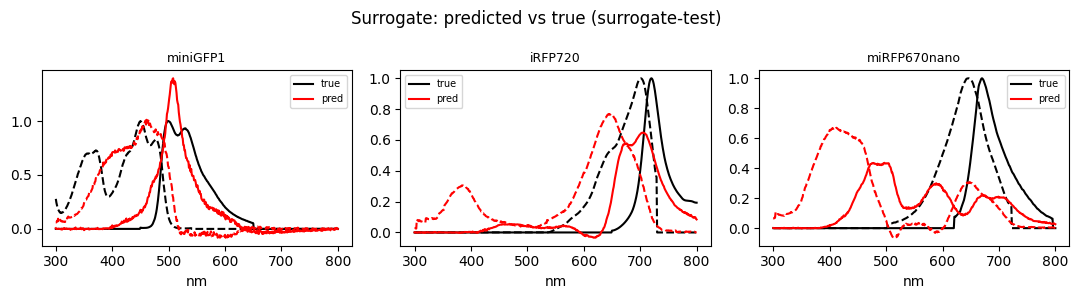

In [7]:
if HAVE_PLT:
    idx = np.where(te)[0][:3]
    plt.figure(figsize=(11,3))
    for k,i in enumerate(idx):
        ax=plt.subplot(1,3,k+1)
        with torch.no_grad(): p = surrogate(Xt[i:i+1]).cpu().numpy()[0]
        ax.plot(grid, Y[i,:G], "k--"); ax.plot(grid, Y[i,G:], "k-", label="true")
        ax.plot(grid, p[:G], "r--"); ax.plot(grid, p[G:], "r-", label="pred")
        ax.set_title(rows[i]["name"][:18], fontsize=9); ax.set_xlabel("nm"); ax.legend(fontsize=7)
    plt.suptitle("Surrogate: predicted vs true (surrogate-test)"); plt.tight_layout(); plt.show()

## 4. Oracle model (RandomForest) — grid search, save, stratified test report

A **different architecture** (tree ensemble) on the same embeddings, predicting a **PCA-reduced** spectrum
(32 comps, ~99.7% variance) for speed. Grid over RF hyperparameters; selected by **oracle-val** MSE; the held-out
**oracle-test** performance is reported **separately for surrogate-train (ID) and surrogate-test (OOD)** regions,
so the judge is certified in both regimes it will be used in.

In [8]:
o_tr = m_ora["train"]; o_va = m_ora["val"]; o_te = m_ora["test"]
PCA_N = 32
pca = PCA(PCA_N, random_state=0).fit(Y[o_tr])
print(f"PCA {PCA_N} comps, explained variance {pca.explained_variance_ratio_.sum():.3f}")
Ytr_p = pca.transform(Y[o_tr])

rf_cfgs = [dict(n_estimators=300, max_depth=md, max_features=mf, min_samples_leaf=ml)
           for md in (None, 12) for mf in ("sqrt", 0.3) for ml in (1, 3)]
best_o = None; t0=time.time()
for cfg in rf_cfgs:
    rf = RandomForestRegressor(n_jobs=-1, random_state=0, **cfg).fit(X[o_tr], Ytr_p)
    vp = pca.inverse_transform(rf.predict(X[o_va])); v = float(((vp - Y[o_va])**2).mean())
    if best_o is None or v < best_o["val"]: best_o = {"val": v, "cfg": cfg, "rf": rf}
print(f"grid search: {len(rf_cfgs)} configs in {time.time()-t0:.0f}s")
print("best config:", best_o["cfg"], f"| val MSE {best_o['val']:.5f}")
oracle_rf = best_o["rf"]

PCA 32 comps, explained variance 0.997


grid search: 8 configs in 12s
best config: {'n_estimators': 300, 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1} | val MSE 0.04484


In [9]:
# save oracle, report stratified on oracle-TEST
joblib.dump({"rf": oracle_rf, "pca": pca, "config": best_o["cfg"], "pca_n": PCA_N},
            os.path.join(TD, "oracle_best.joblib"))
print("saved", os.path.join(TD, "oracle_best.joblib"))

def o_predict(mask):
    return pca.inverse_transform(oracle_rf.predict(X[mask]))

print("\nOracle performance (oracle-test), stratified by surrogate region:")
all_te = o_te
report("oracle  ALL test", Y[all_te], o_predict(all_te), EXM[all_te], EMM[all_te])
id_te  = o_te & (sur=="train")    # surrogate-seen region (ID)
ood_te = o_te & (sur=="test")     # surrogate-unseen region (OOD)
report("oracle  ID  (sur-train)", Y[id_te],  o_predict(id_te),  EXM[id_te],  EMM[id_te])
report("oracle  OOD (sur-test)",  Y[ood_te], o_predict(ood_te), EXM[ood_te], EMM[ood_te])
report("baseline (mean spec)",    Y[all_te], np.repeat(baseline, all_te.sum(),0), EXM[all_te], EMM[all_te])

def oracle_spectrum(ss):
    if isinstance(ss, str): ss=[ss]
    return torch.tensor(pca.inverse_transform(oracle_rf.predict(embed(ss))), dtype=torch.float32, device=dev)

saved training_data/oracle_best.joblib

Oracle performance (oracle-test), stratified by surrogate region:
  oracle  ALL test       MSE 0.06926 | ex_max MAE  80.1 nm | em_max MAE  79.3 nm  (n=101)


  oracle  ID  (sur-train) MSE 0.07679 | ex_max MAE  92.6 nm | em_max MAE 100.0 nm  (n=56)


  oracle  OOD (sur-test) MSE 0.05989 | ex_max MAE  64.7 nm | em_max MAE  53.4 nm  (n=45)
  baseline (mean spec)   MSE 0.07281 | ex_max MAE  96.1 nm | em_max MAE 104.3 nm  (n=101)


## 5. Pseudo-perplexity (naturalness, for ranking)

In [10]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _,_,base = bc([("s", seq.strip().upper())]); base = base[0].to(dev)
    res = [i for i,t in enumerate(base.tolist()) if t not in SPECIAL]
    tot = 0.0
    for s in range(0, len(res), batch_size):
        ch = res[s:s+batch_size]; bt = base.unsqueeze(0).repeat(len(ch),1).clone()
        for r,p in enumerate(ch): bt[r,p] = alphabet.mask_idx
        lp = torch.log_softmax(model(bt)["logits"], dim=-1)
        for r,p in enumerate(ch): tot += float(lp[r,p,base[p]])
    n=len(res); return tot, np.exp(-tot/n)

## 6. Guided refinement (surrogate guides, oracle evaluates)

Same loop as the synthetic notebook, now wired to the **real** models: candidate scoring uses the surrogate
`g`; the per-sweep trace and all evaluation use the independent oracle.

In [11]:
def to_tokens(seq):
    _,_,t = bc([("q", seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d):
    return "".join(alphabet.get_tok(int(t)) for t in t1d if int(t) not in SPECIAL)

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None,
                  eval_fn=None, verbose=True):
    toks = to_tokens(seq)
    res = [i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res = [res[j] for j in editable]
    tnorm = float(torch.sum(target**2)) + 1e-8
    trace = []
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos] = alphabet.mask_idx
            lg = model(toks)["logits"][0,pos].masked_fill(~AA_MASK, float("-inf"))
            logp = torch.log_softmax(lg, -1); topv, topi = torch.topk(logp, k)
            cand = []
            for idx in topi.tolist():
                toks[0,pos] = idx; cand.append(tokens_to_seq(toks[0]))
            d = torch.sum((g_spectrum(cand) - target.unsqueeze(0))**2, 1) / tnorm   # surrogate guidance
            lpz = (topv - topv.mean())/(topv.std()+1e-6); dz = (d - d.mean())/(d.std()+1e-6)
            scores = lpz - lam*dz
            ch = (torch.multinomial(torch.softmax(scores/temperature,-1),1).item()
                  if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos] = int(topi[ch].item())
        cur = tokens_to_seq(toks[0])
        ev = (eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0])           # oracle evaluation
        err = float(torch.sum((ev - target)**2)/tnorm); trace.append(err)
        if verbose: print(f"  sweep {sweep}: oracle error {err:.4f}")
    return tokens_to_seq(toks[0]), trace

## 7. Design + evaluation: ID vs OOD targets

Design toward held-out target spectra (the oracle-test pool, which doubles as cert + targets), starting from a
fixed GFP-family scaffold and refining an editable window. Success is **oracle-judged**, reported for ID
(surrogate-seen) vs OOD (surrogate-unseen) targets.

> Scoped demo: a few targets, one sweep, a generic editable window — each refinement is many ESM forward
> passes. Increase `N_ID/N_OOD`, `N_SWEEPS`, `WINDOW`, or target chromophore-region positions to scale up.

In [12]:
N_ID, N_OOD, N_SWEEPS, K_TOP, LAM, WINDOW = 3, 3, 1, 6, 5.0, 40

# scaffold = a surrogate-train sequence from the largest cluster (GFP family)
big = int(np.bincount(cluster[m_sur["train"]]).argmax())
scaffold_idx = next(i for i in range(N) if cluster[i]==big and sur[i]=="train")
scaffold = seqs[scaffold_idx]
L = len(scaffold); mid = L//2
editable = list(range(max(0, mid-WINDOW//2), min(L, mid+WINDOW//2)))
print(f"scaffold: {rows[scaffold_idx]['name']} (len {L}) | editable residues {editable[0]}-{editable[-1]}")

id_targets  = list(np.where(o_te & (sur=="train"))[0])[:N_ID]
ood_targets = list(np.where(o_te & (sur=="test"))[0])[:N_OOD]

def run_targets(tids, label):
    out=[]
    for i in tids:
        tspec = torch.tensor(Y[i], device=dev)
        tnorm = float(torch.sum(tspec**2))+1e-8
        d0 = float(torch.sum((oracle_spectrum(scaffold)[0]-tspec)**2)/tnorm)
        des,_ = guided_refine(scaffold, tspec, n_sweeps=N_SWEEPS, k=K_TOP, lam=LAM,
                              editable=editable, eval_fn=oracle_spectrum, verbose=False)
        d1 = float(torch.sum((oracle_spectrum(des)[0]-tspec)**2)/tnorm)
        _, ppl = pseudo_perplexity(des)
        out.append(dict(idx=i, name=rows[i]["name"], draft=d0, refined=d1, ppl=ppl, design=des))
        print(f"  [{label}] {rows[i]['name'][:20]:20s} draft {d0:.4f} -> refined {d1:.4f} (oracle) | ppl {ppl:.2f}")
    return out

print("ID targets (surrogate-seen):"); id_res  = run_targets(id_targets, "ID")
print("OOD targets (surrogate-unseen):"); ood_res = run_targets(ood_targets, "OOD")
import numpy as _np
print(f"\nmean oracle error  ID:  draft {_np.mean([r['draft'] for r in id_res]):.4f} -> refined {_np.mean([r['refined'] for r in id_res]):.4f}")
print(f"mean oracle error  OOD: draft {_np.mean([r['draft'] for r in ood_res]):.4f} -> refined {_np.mean([r['refined'] for r in ood_res]):.4f}")

scaffold: htFuncLib_fast.2 (len 248) | editable residues 104-143
ID targets (surrogate-seen):


  [ID] Maroon0.1            draft 1.5451 -> refined 0.8621 (oracle) | ppl 13.04


  [ID] Electra2             draft 1.4078 -> refined 0.8948 (oracle) | ppl 13.89


  [ID] super-TagRFP         draft 1.6682 -> refined 0.5053 (oracle) | ppl 12.82
OOD targets (surrogate-unseen):


  [OOD] miniGFP1             draft 0.3387 -> refined 0.4687 (oracle) | ppl 15.15


  [OOD] iRFP720              draft 1.7900 -> refined 1.2609 (oracle) | ppl 13.88


  [OOD] miRFP670             draft 1.6919 -> refined 1.0730 (oracle) | ppl 13.29

mean oracle error  ID:  draft 1.5404 -> refined 0.7541
mean oracle error  OOD: draft 1.2735 -> refined 0.9342


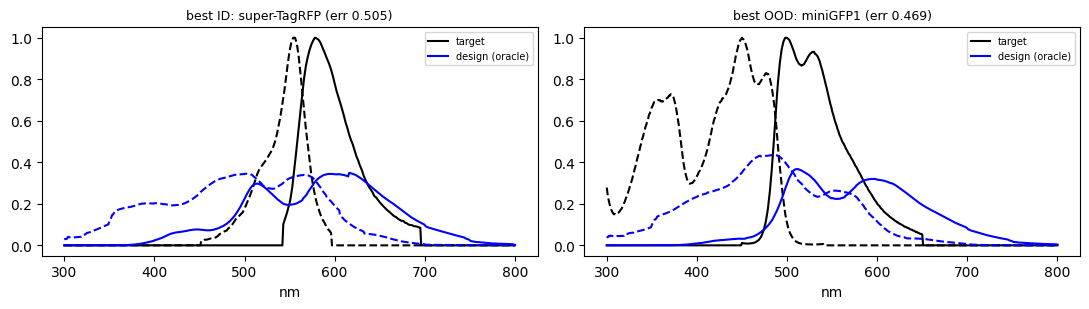

In [13]:
if HAVE_PLT and id_res and ood_res:
    bi = min(id_res, key=lambda r:r["refined"]); bo = min(ood_res, key=lambda r:r["refined"])
    plt.figure(figsize=(11,3.2))
    for k,(r,lab) in enumerate([(bi,"best ID"),(bo,"best OOD")]):
        ax=plt.subplot(1,2,k+1); t=Y[r["idx"]]; rspec=oracle_spectrum(r["design"])[0].cpu().numpy()
        ax.plot(grid, t[:G], "k--"); ax.plot(grid, t[G:], "k-", label="target")
        ax.plot(grid, rspec[:G], "b--"); ax.plot(grid, rspec[G:], "b-", label="design (oracle)")
        ax.set_title(f"{lab}: {r['name'][:18]} (err {r['refined']:.3f})", fontsize=9)
        ax.set_xlabel("nm"); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## Notes

- **Saved artifacts:** `training_data/surrogate_best.pt`, `training_data/oracle_best.joblib`,
  `training_data/esm_embeddings.npy` (cache).
- **Honest results:** real FP spectra are only modestly predictable from mean-pooled embeddings (MSE not far
  below the mean-spectrum baseline; ex/em MAE is the interpretable number). This reflects the
  *few-residue/chromophore* nature of color (see clustering analysis) — mean-pooling blunts it. A position-aware
  surrogate (per-residue / chromophore-focused features) is the likely upgrade, and motivates **Approach 2**
  (FiLM adaptor + conditional MLM).
- **Evaluation honesty:** guidance uses the surrogate; the oracle (different architecture) judges, and its
  accuracy is certified separately for ID/OOD. Remember the oracle is validated on *natural* sequences — trust
  its verdict less as designs drift off-manifold (keep pseudo-perplexity low).